--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


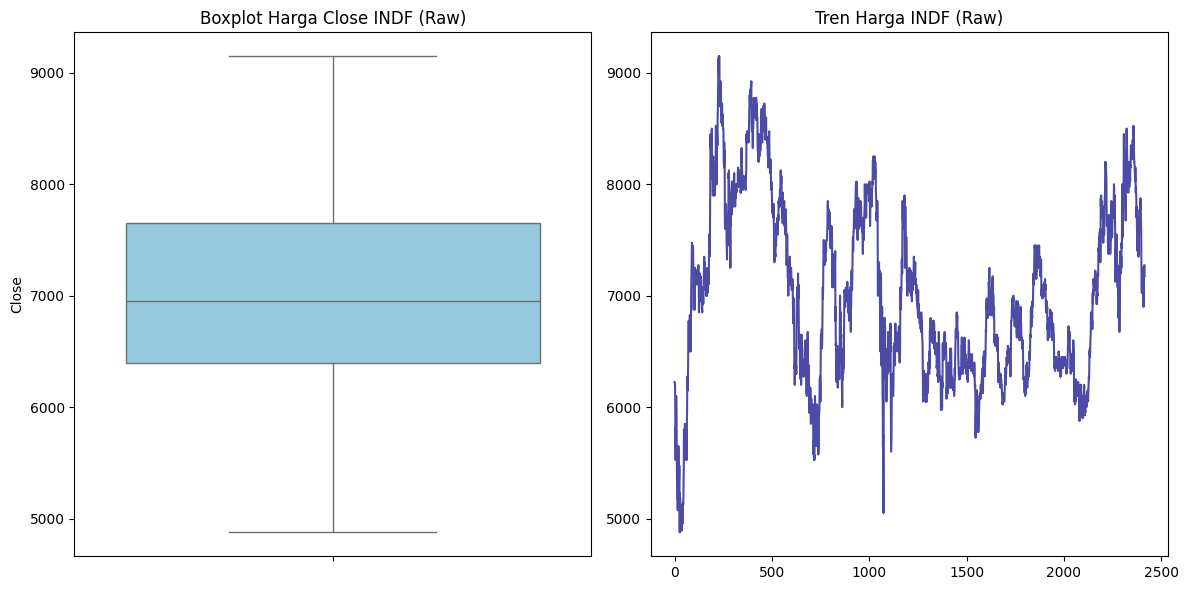


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')

# KOREKSI: Hapus duplikat tanggal yang benar
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS DENGAN BOXPLOT (PADA DATA ASLI)
plt.figure(figsize=(12, 6))

# Subplot 1: Boxplot untuk melihat sebaran statistik
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Close'], color='skyblue')
plt.title('Boxplot Harga Close INDF (Raw)')

# Subplot 2: Time Series Plot untuk melihat lokasi gap/lonjakan
plt.subplot(1, 2, 2)
plt.plot(df.index, df['Close'], color='navy', alpha=0.7)
plt.title('Tren Harga INDF (Raw)')

plt.tight_layout()
plt.show()

# Hitung Statistik Outliers (Metode IQR)
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")

if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [2]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [10]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
# Set Date sebagai index untuk proses reindexing
df_indexed = df.set_index('Date')

# Reindexing ke kalender hari kerja agar gap (NaN) muncul
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2 (Agar libur panjang melengkung alami)
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)

# Handle sisa NaN di ujung data
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI & PENYIMPANAN
scaler = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler.fit_transform(df_complete[['Close']])

# Simpan hasil akhir
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir: {len(df_final)}")
print(f"Data disimpan ke: 'INDF_Cleaned.csv'")

✅ Pra-pemrosesan Selesai!
Total Baris Akhir: 2609
Data disimpan ke: 'INDF_Cleaned.csv'


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# Agar hasil eksperimen bisa direproduksi (adil)
tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values

# Parameter Tetap
WINDOW_SIZE = 30

# Fungsi untuk membuat window (seperti sebelumnya)
def create_window_dataset(dataset, lookback):
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    print(f"\n>>> MENJALANKAN SKENARIO {int(ratio_train*100)}:{int(ratio_val*100)}:{int(ratio_test*100)} ...")
    
    n = len(data_full)
    n_train = int(ratio_train * n)
    n_val = int(ratio_val * n)
    # Sisanya buat test (biar total pas 100%)
    n_test = n - n_train - n_val 
    
    # 1. Splitting
    train_data = data_full[:n_train]
    val_data   = data_full[n_train:n_train+n_val]
    test_data  = data_full[-n_test:]
    
    # 2. Scaling (FIT HANYA DI TRAIN!)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    val_scaled   = scaler.transform(val_data)
    test_scaled  = scaler.transform(test_data)
    
    # 3. Windowing
    X_train, y_train = create_window_dataset(train_scaled, WINDOW_SIZE)
    X_val, y_val     = create_window_dataset(val_scaled, WINDOW_SIZE)
    X_test, y_test   = create_window_dataset(test_scaled, WINDOW_SIZE)
    
    print(f"   Shape Train: {X_train.shape}")
    print(f"   Shape Val  : {X_val.shape}")
    print(f"   Shape Test : {X_test.shape}")
    
    # KEMBALIKAN DATA YANG SUDAH SIAP
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler # Scaler butuh disimpan buat invers nanti
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama_skenario = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    
    # Panggil fungsi di atas
    datasets[nama_skenario] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ SEMUA SKENARIO SUDAH DIPROSES & DISIMPAN!")
print("Cara akses data: datasets['80-10-10']['X_train']")

d:\Kuliah\Semester7\PraTA\env_ta\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):



>>> MENJALANKAN SKENARIO 80:10:10 ...
   Shape Train: (2057, 30, 1)
   Shape Val  : (230, 30, 1)
   Shape Test : (232, 30, 1)

>>> MENJALANKAN SKENARIO 70:15:15 ...
   Shape Train: (1796, 30, 1)
   Shape Val  : (361, 30, 1)
   Shape Test : (362, 30, 1)

>>> MENJALANKAN SKENARIO 60:20:20 ...
   Shape Train: (1535, 30, 1)
   Shape Val  : (491, 30, 1)
   Shape Test : (493, 30, 1)

✅ SEMUA SKENARIO SUDAH DIPROSES & DISIMPAN!
Cara akses data: datasets['80-10-10']['X_train']
